# Backpropagation (TensorFlow)

Backpropagation is the algorithm that trains neural networks: it applies the chain
rule to propagate the error from the output layer back through every earlier layer,
producing a gradient for every weight. An optimizer then nudges each weight a small
step against its gradient.

Here we build a tiny 2-layer MLP **from raw `tf.Variable`s** on the `sklearn` digits
dataset, using `tf.GradientTape` to record the forward pass and compute gradients
explicitly, so backpropagation is visible rather than hidden inside `model.fit()`.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(0)

In [2]:
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train = tf.constant(scaler.transform(X_train), dtype=tf.float32)
X_test = tf.constant(scaler.transform(X_test), dtype=tf.float32)
y_train = tf.constant(y_train, dtype=tf.int64)
y_test = tf.constant(y_test, dtype=tf.int64)

In [3]:
n_in, n_hidden, n_out = 64, 32, 10

W1 = tf.Variable(tf.random.normal((n_in, n_hidden), stddev=0.1))
b1 = tf.Variable(tf.zeros(n_hidden))
W2 = tf.Variable(tf.random.normal((n_hidden, n_out), stddev=0.1))
b2 = tf.Variable(tf.zeros(n_out))
params = [W1, b1, W2, b2]


def forward(x):
    z1 = tf.matmul(x, W1) + b1
    a1 = tf.nn.relu(z1)
    z2 = tf.matmul(a1, W2) + b2
    return z2


loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
lr = 0.05

In [4]:
losses, grad_norms = [], []
for epoch in range(60):
    with tf.GradientTape() as tape:           # records every op on params for backprop
        logits = forward(X_train)
        loss = loss_fn(y_train, logits)

    grads = tape.gradient(loss, params)        # <-- backpropagation happens here
    grad_norm = sum(tf.norm(g).numpy() for g in grads)

    for p, g in zip(params, grads):
        p.assign_sub(lr * g)                   # manual gradient descent step

    losses.append(loss.numpy())
    grad_norms.append(grad_norm)
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:3d}  loss {loss.numpy():.4f}  |grad| {grad_norm:.4f}")

epoch  10  loss 2.1047  |grad| 1.0107
epoch  20  loss 1.8983  |grad| 1.0102
epoch  30  loss 1.6913  |grad| 1.0175
epoch  40  loss 1.4880  |grad| 1.0039
epoch  50  loss 1.2995  |grad| 0.9608
epoch  60  loss 1.1342  |grad| 0.8974


Test accuracy: 0.781


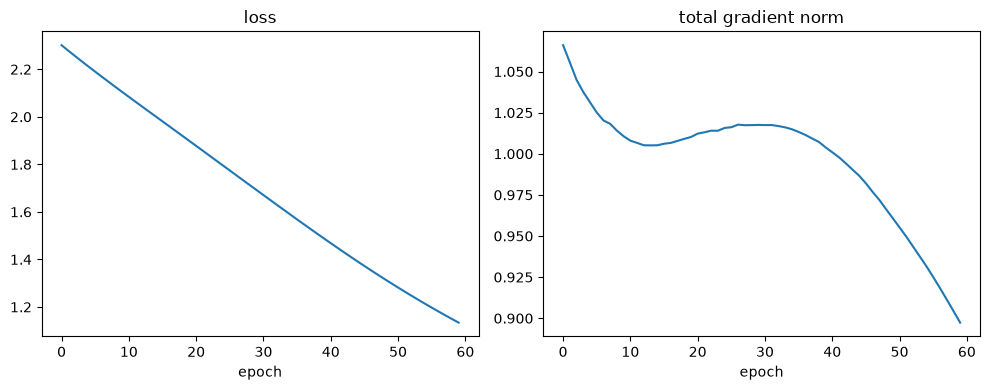

In [5]:
preds = tf.argmax(forward(X_test), axis=1)
accuracy = tf.reduce_mean(tf.cast(preds == y_test, tf.float32)).numpy()
print(f"Test accuracy: {accuracy:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(losses); axes[0].set_title("loss"); axes[0].set_xlabel("epoch")
axes[1].plot(grad_norms); axes[1].set_title("total gradient norm"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()